# Ex. Single ERT File Inversion (No Time-Lapse)

This notebook shows a simple one-file ERT workflow using `ert_data_agent` functions directly:
1. Set a folder path or file path (default uses DAS example data).
2. Process data (`load_ert_resipy`, `qc_and_visualize`, `export_for_inversion`).
3. Run one `ERTInversion`.
4. Save model outputs.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pygimli as pg

try:
    current_dir = Path(__file__).resolve().parent
except NameError:
    current_dir = Path.cwd()

if (current_dir / "data" / "ERT").exists():
    examples_dir = current_dir
elif (current_dir / "examples" / "data" / "ERT").exists():
    examples_dir = current_dir / "examples"
else:
    examples_dir = current_dir

repo_root = examples_dir.parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from PyHydroGeophysX.data_processing.ert_data_agent import (
    LocalRef,
    export_for_inversion,
    load_ert_resipy,
    qc_and_visualize,
)
from PyHydroGeophysX.inversion.ert_inversion import ERTInversion

c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\PyHydroGeophysX\__init__.py:15: FutureWarning: Importing `SimPEG` is deprecated. please import from `simpeg`.
  import SimPEG as _simpeg


API path =  c:\Users\hchen117\.conda\envs\pg\Lib\site-packages\resipy
ResIPy version =  3.6.3
cR2.exe found and up to date.
R3t.exe found and up to date.
cR3t.exe found and up to date.
[PyHydroGeophysX] RESIPY loaded successfully
[PyHydroGeophysX] PyGIMLi loaded successfully
[PyHydroGeophysX] SimPEG loaded successfully (version 0.25.0)


In [2]:
# Default dataset requested: examples/data/ERT/DAS
input_path = examples_dir / "data" / "ERT" / "Bert"
instrument = "BERT" 

output_dir = examples_dir / "results" / "ert_single_inversion_notebook"
output_dir.mkdir(parents=True, exist_ok=True)

# Pick first file from the folder
candidates = sorted(list(input_path.glob("*.Data")) + list(input_path.glob("*.data")) + list(input_path.glob("*.dat")))
if not candidates:
    raise FileNotFoundError(f"No ERT data file found in {input_path}")
data_file = candidates[0]

print(f"Input folder: {input_path}")
print(f"Using file: {data_file}")
print(f"Output dir: {output_dir}")

Input folder: c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\data\ERT\Bert
Using file: c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\data\ERT\Bert\fielddataline2.dat
Output dir: c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\results\ert_single_inversion_notebook


In [3]:
ert = load_ert_resipy(
    project_dir=str(input_path),
    data_file=str(data_file),
    instrument=instrument,
    crs="local",
    local_ref=LocalRef(origin_x=0.0, origin_y=0.0, azimuth_deg=90.0),
)

artifacts = qc_and_visualize(ert, outdir=str(output_dir))
bert_path = export_for_inversion(ert, outdir=str(output_dir), fmt="pgimli")

print(f"Instrument used: {instrument}")
print(f"BERT export: {bert_path}")
print("QC artifacts:")
for k, v in artifacts.items():
    print(f"  {k}: {v}")

Working directory is: c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\data\ERT\Bert
Working directory is: C:\Users\hchen117\AppData\Local\Temp\resipy_6t57t07a
   Detected shifted ABMN indices from PyGIMLi loader; applied +1 correction.


c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\PyHydroGeophysX\data_processing\ert_data_agent.py:1369: UserWarning: RESIPY cannot prepare project directory 'c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\data\ERT\Bert' (PermissionError). Falling back to a temporary project directory.
  warnings.warn(
c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\PyHydroGeophysX\data_processing\ert_data_agent.py:1430: UserWarning: RESIPY failed to parse 'fielddataline2.dat' ('0'). Falling back to embedded parsers/PyGIMLi loader.
  warnings.warn(
20/02/26 - 16:18:44 - pyGIMLi - INFO - Cache c:\Users\hchen117\.conda\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (2.7s x 2): C:\Users\hchen117\AppData\Roaming\pygimli\Cache\11636768490264181462


   DEBUG: Writing 72 electrodes to file
   DEBUG: First electrode: x=0.000, y=-8.727, z=0.000
   DEBUG: Last electrode: x=70.188, y=0.000, z=0.000
   DEBUG: Coordinate ranges: x=[0.000, 70.188], y=[-8.727, 0.000], z=[0.000, 0.000]
   DEBUG: Inferred elevation axis: y
   DEBUG: app_res source metadata: rhoa
   DEBUG: Treating app_res as apparent resistivity (rhoa) for K-handling.
   DEBUG: Error mode: reciprocal (auto-estimated)
   DEBUG: Reciprocal-error estimate on export rows: paired=0/936, err_range=[0.050, 0.050]
   DEBUG: Wrote 936 valid observations
   Exported data to c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\results\ert_single_inversion_notebook\bert_data.dat
   Validating geometric factors... [CODE-VERSION: 2026-02-20-v4-safe-export]
   DEBUG: PyGIMLi loaded 72 electrode positions
   DEBUG: Loaded coordinate ranges: x=[0.000, 70.188], y=[-8.727, 0.000], z=[0.000, 0.000]
   DEBUG: Inferred elevation axis (loaded): y
   Computing g

In [4]:
inversion = ERTInversion(
    data_file=bert_path,
    lambda_val=10.0,
    method="cgls",
    max_iterations=10,
    lambda_rate=1.0,
    use_gpu=False,
)
result = inversion.run()

20/02/26 - 16:18:44 - pyGIMLi - INFO - Found 2 regions.
20/02/26 - 16:18:44 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
20/02/26 - 16:18:44 - pyGIMLi - INFO - Found 2 regions.
20/02/26 - 16:18:44 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
20/02/26 - 16:18:44 - pyGIMLi - INFO - Creating forward mesh from region infos.


DEBUG [ert_inversion.py]: Data has 72 electrode positions before mesh creation
DEBUG [ert_inversion.py]: Electrode Y-range (elevation): [-8.727, 0.000]
DEBUG [ert_inversion.py]: Mesh created with 996 nodes, 1794 cells
DEBUG [ert_inversion.py]: Mesh Y-range: [-317.555, 0.000]
   Using provided error estimates (mean: 0.0500, range: [0.0500, 0.0500])


20/02/26 - 16:18:44 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
20/02/26 - 16:18:44 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 3785 Cells: 7176 Boundaries: 5578


-------------------Iteration: 0 ---------------------------
chi2: 48.22298149217207
dPhi: 1.0
-------------------Iteration: 1 ---------------------------
chi2: 4.631301147906223
dPhi: 0.9039607049460845
-------------------Iteration: 2 ---------------------------
chi2: 0.9421187287359093
dPhi: 0.7965758004828007
End of inversion


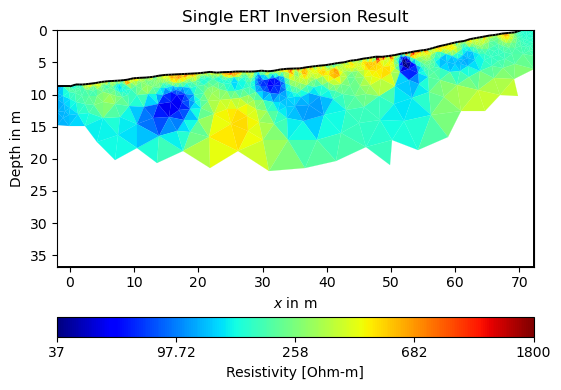

Saved model figure: c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\examples\results\ert_single_inversion_notebook\single_ert_model_notebook.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 4))


pg.show(
    result.mesh,
    result.final_model,
    ax=ax,
    cMap="jet",
    logScale=True,
    coverage=result.coverage>-1,
    label="Resistivity [Ohm-m]",
)
ax.set_title("Single ERT Inversion Result")
fig.tight_layout()

fig_path = output_dir / "single_ert_model_notebook.png"
fig.savefig(fig_path, dpi=200)
plt.show()

np.save(output_dir / "final_model.npy", result.final_model)
np.save(output_dir / "predicted_data.npy", result.predicted_data)
np.save(output_dir / "coverage.npy", result.coverage)
print(f"Saved model figure: {fig_path}")

(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>,
 <matplotlib.colorbar.Colorbar at 0x1b200e47090>)

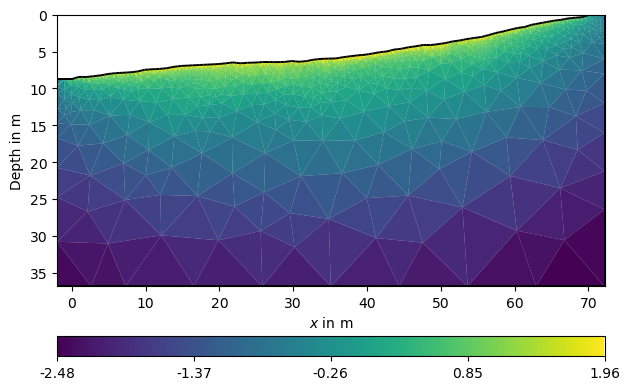

In [9]:
pg.show(result.mesh,result.coverage)

To run the script version from terminal:

```bash
python examples/Ex_ERT_single_inversion.py --input examples/data/ERT/DAS --instrument DAS-1
```